# Importando bibliotecas

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio
from scipy.io import wavfile

# Baixando um dataset (cat / dog)
Fonte: https://github.com/1fmusic/Audio_cat_dog_classification

In [ ]:
!git clone https://github.com/1fmusic/Audio_cat_dog_classification

Cloning into 'Audio_cat_dog_classification'...
remote: Enumerating objects: 987, done.
remote: Total 987 (delta 0), reused 0 (delta 0), pack-reused 987
Receiving objects: 100% (987/987), 359.50 MiB | 28.28 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Checking out files: 100% (1025/1025), done.


# Cat sound

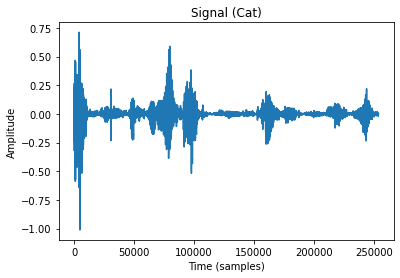

In [ ]:
y, sr = librosa.load('./Audio_cat_dog_classification/cats/cat_6.wav')
plt.plot(y);
plt.title('Signal (Cat)');
plt.xlabel('Time (samples)');
plt.ylabel('Amplitude');

In [ ]:
y.shape

(253575,)

In [ ]:
# Load the file on an object
data = wavfile.read('./Audio_cat_dog_classification/cats/cat_6.wav')

# Separete the object elements
framerate = data[0]
sounddata = data[1]
time      = np.arange(0,len(sounddata))/framerate

# Show information about the object
print('Sample rate:',framerate,'Hz')
print('Total time:',len(sounddata)/framerate,'s')

# Generate a player for mono sound
Audio(sounddata,rate=framerate)

Sample rate: 16000 Hz
Total time: 11.5 s


# Dog sound

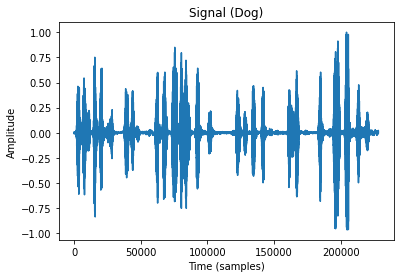

In [ ]:
y, sr = librosa.load('./Audio_cat_dog_classification/dogs/dog_barking_5.wav')
plt.plot(y);
plt.title('Signal (Dog)');
plt.xlabel('Time (samples)');
plt.ylabel('Amplitude');

In [ ]:
y

array([-0.00447938, -0.00616756, -0.00654972, ...,  0.00705702,
        0.0066308 ,  0.        ], dtype=float32)

In [ ]:
# Load the file on an object
data = wavfile.read('./Audio_cat_dog_classification/dogs/dog_barking_5.wav')

# Separete the object elements
framerate = data[0]
sounddata = data[1]
time      = np.arange(0,len(sounddata))/framerate

# Show information about the object
print('Sample rate:',framerate,'Hz')
print('Total time:',len(sounddata)/framerate,'s')

# Generate a player for mono sound
Audio(sounddata,rate=framerate)

Sample rate: 16000 Hz
Total time: 10.346875 s


# Transformada de Fourier

## Cat Spectrum

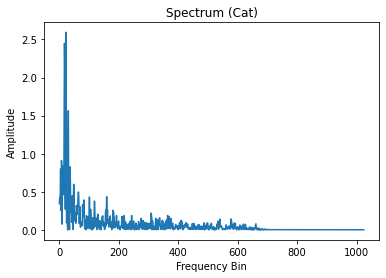

In [ ]:
import numpy as np

y, sr = librosa.load('./Audio_cat_dog_classification/cats/cat_3.wav')
n_fft = 2048
ft = np.abs(librosa.stft(y[:n_fft], hop_length = n_fft+1))
plt.plot(ft);
plt.title('Spectrum (Cat)');
plt.xlabel('Frequency Bin');
plt.ylabel('Amplitude');

In [ ]:
ft

array([[0.34350982],
       [0.4246751 ],
       [0.39410925],
       ...,
       [0.00217558],
       [0.00217564],
       [0.00217567]], dtype=float32)

# Dog Spectrum

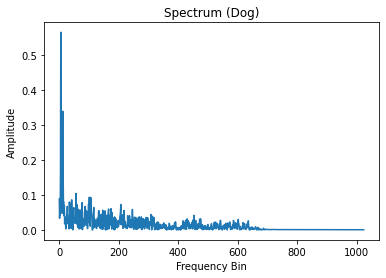

In [ ]:
y, sr = librosa.load('./Audio_cat_dog_classification/dogs/dog_barking_3.wav')
n_fft = 2048
ft = np.abs(librosa.stft(y[:n_fft], hop_length = n_fft+1))
plt.plot(ft);
plt.title('Spectrum (Dog)');
plt.xlabel('Frequency Bin');
plt.ylabel('Amplitude');

In [ ]:
ft

array([[0.08880629],
       [0.03328805],
       [0.07246011],
       ...,
       [0.00073245],
       [0.00073246],
       [0.00073246]], dtype=float32)

# Spectrogram Cat

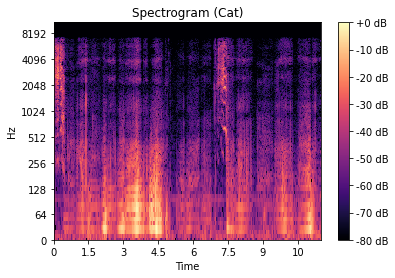

In [ ]:
y, sr = librosa.load('./Audio_cat_dog_classification/cats/cat_6.wav')
spec = np.abs(librosa.stft(y, hop_length=512,))
spec = librosa.amplitude_to_db(spec, ref=np.max)
librosa.display.specshow(spec, sr=sr, x_axis='time', y_axis='log');
plt.colorbar(format='%+2.0f dB');
plt.title('Spectrogram (Cat)');

# Spectrogram Dog

Text(0.5, 1.0, 'Spectrogram (Dog)')

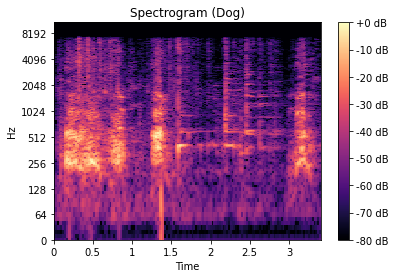

In [ ]:
y, sr = librosa.load('./Audio_cat_dog_classification/dogs/dog_barking_3.wav')
spec = np.abs(librosa.stft(y, hop_length=512))
spec = librosa.amplitude_to_db(spec, ref=np.max)
librosa.display.specshow(spec, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram (Dog)')

# Mel Spectrogram Cat

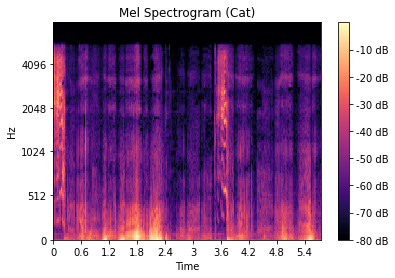

In [ ]:
y, sr = librosa.load('./Audio_cat_dog_classification/cats/cat_6.wav')
mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=1024)
mel_spect = librosa.power_to_db(mel_spect, ref=np.max)
librosa.display.specshow(mel_spect, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram (Cat)');
plt.colorbar(format='%+2.0f dB');

# Mel Spectrogram Dog

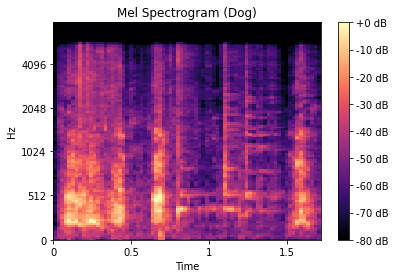

In [ ]:
y, sr = librosa.load('./Audio_cat_dog_classification/dogs/dog_barking_3.wav')
mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=1024)
mel_spect = librosa.power_to_db(mel_spect, ref=np.max)
librosa.display.specshow(mel_spect, y_axis='mel', fmax=8000, x_axis='time');
plt.title('Mel Spectrogram (Dog)');
plt.colorbar(format='%+2.0f dB');

In [ ]:
mel_spect

array([[-63.51813 , -64.57662 , -56.69342 , ..., -63.87945 , -65.69524 ,
        -59.038544],
       [-48.94031 , -42.60677 , -38.480446, ..., -52.573982, -53.126747,
        -51.919823],
       [-52.833355, -40.792206, -38.791996, ..., -47.71321 , -51.834873,
        -48.913136],
       ...,
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ],
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ],
       [-80.      , -80.      , -80.      , ..., -80.      , -80.      ,
        -80.      ]], dtype=float32)

In [ ]:
mel_spect.shape

(128, 74)